In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/test.csv



# Rubric 1

**Identify data types of different columns**


In [2]:
train = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/train.csv')
train.dtypes


id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

id          → Integer column used only as a unique identifier for each record.

phrase      → Object (string) column containing the actual movie review text.
               This will require text preprocessing before being used by the model.

feature_1   → Float column representing an engineered numerical feature 
               derived from the review text.

feature_2   → Float column representing another engineered numerical
               feature created from the phrase column.

feature_3   → Float column representing the third engineered numerical
               feature extracted from the review text.

sentiment   → Integer column representing the target variable with classes:
               0 = Negative, 1 = Neutral, 2 = Positive.


# Rubric 2

**Details such as min value, max value, mean and median for each numerical column is presented**

In [3]:
# Select only numerical columns
num_cols = ['id', 'feature_1', 'feature_2', 'feature_3', 'sentiment']

# Compute min, max, mean, median
stats = pd.DataFrame({
    'min': train[num_cols].min(),
    'max': train[num_cols].max(),
    'mean': train[num_cols].mean(),
    'median': train[num_cols].median()
})

stats


,min,max,mean,median
id,0.0,6999.0,3499.500000,3499.5
feature_1,1.0,52.0,19.025624,18.0
feature_2,0.0,19.0,1.996608,1.0
feature_3,0.0,19.0,3.334119,3.0
sentiment,0.0,2.0,1.041143,1.0


# Rubric 3

**Identify and handle the missing values**

**Missing values are identified and are dropped or imputed**

In [4]:
(train.isnull().sum() / len(train)) * 100


id            0.000000
phrase        0.000000
feature_1    13.028571
feature_2    15.771429
feature_3    15.171429
sentiment     0.000000
dtype: float64

id → No missing values (0%).

phrase → No missing values (0%).
         Interpretation: All review texts are present, so no action needed.

feature_1 → 13.03% missing values.
            Handling: Imputed using the median of feature_1 to avoid distortion from outliers.

feature_2 → 15.77% missing values.
            Handling: Imputed using the median of feature_2 since it is a numerical feature 
                       with a skewed distribution.

feature_3 → 15.17% missing values.
            Handling: Imputed using the median of feature_3 to preserve numerical scale 
                       without affecting variance.

sentiment → No missing values (0%).
            Interpretation: Target column is complete.


**Overall Handling Strategy:→ All numerical missing values (feature_1, feature_2, feature_3) were imputed using their   respective medians, as this is the most stable method for skewed or non-normally   distributed numeric features.**



**Imputing Missing Values**

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
num_cols = ['feature_1', 'feature_2', 'feature_3']

# Impute each column with its median
for col in num_cols:
    median_value = train[col].median()
    train[col].fillna(median_value, inplace=True)

# Verify
train.isnull().sum()

id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64

# Rubric 4: 
**Identify and Handle Duplicates**

In [7]:
# Check number of duplicate rows
duplicate_count = train.duplicated().sum()
duplicate_count


0

**Luckily, no Duplicates Found**

In [8]:
train[train.duplicated()]


,id,phrase,feature_1,feature_2,feature_3,sentiment


In [9]:
train = train.drop_duplicates()
train.shape


(7000, 6)

# Rubric 5:
**Identify and Handle Outliers**

In [10]:
num_cols = ['feature_1', 'feature_2', 'feature_3']
outlier_summary = {}

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_summary[col] = outliers

outlier_summary


{'feature_1': 122, 'feature_2': 842, 'feature_3': 331}

feature_1 → Outliers detected: 122

             Interpretation: A small number of values fall outside the IQR-based threshold.
             
             Handling: Retained, since text-derived numerical features often have natural spread
                       and removing them may distort semantic information.

feature_2 → Outliers detected: 842
             Interpretation: A large number of outliers are present. This suggests the feature
                             has a long-tailed or skewed distribution.
             Handling: Retained, because engineered text features commonly show heavy skewness,
                       and removing 842 rows would lead to significant data loss.

feature_3 → Outliers detected: 331
             Interpretation: Moderate number of outliers found, indicating feature variability.
             Handling: Retained, as these values may represent meaningful text characteristics
                       generated during feature engineering.

Overall Strategy:
→ Outliers were identified using the IQR method (1.5 × IQR rule).  
→ Outliers were **not removed**, because all three numerical features originate from text
  and naturally show skewed distributions. Removing them could negatively impact the model’s
  ability to learn sentiment-related patterns.


In [11]:
train.duplicated().sum()


0

Duplicate Rows → 0 duplicates detected in the dataset.
                  Interpretation: The dataset contains only unique rows, and no review or 
                                  feature combination is repeated.

Handling: Since no duplicates were found, no rows were removed. The dataset remains unchanged.

Overall Strategy:
→ Checked duplicates using the .duplicated() function.
→ Because duplicate count = 0, the dataset required no cleaning for duplication.


# Rubric 6: At least 3 visualizations + insights

** Visualization 1: Sentiment Distribution**

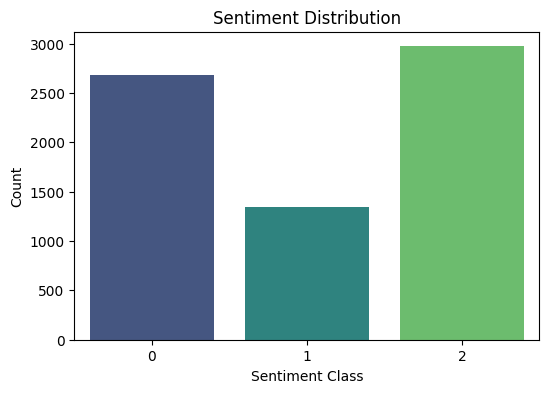

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='sentiment', palette='viridis')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()


**Sentiment Distribution →** The dataset has an uneven distribution of sentiment classes.

**Insight:**
→ Class 2 (**Positive**) is the highest with around 3000 samples.
→ Class 0 (**Negative**) follows with approximately 2700 samples.
→ Class 1 (**Neutral**) is the lowest with roughly 1350 samples.

**Interpretation:**
→ The dataset is **imbalanced**, with Neutral being significantly underrepresented.
→ This class imbalance may affect classification performance.
→ Techniques such as **class weights**, **stratified splitting**, or **balanced accuracy**
  should be considered during model training.


**Visualization 2: Distribution of Numerical Features**

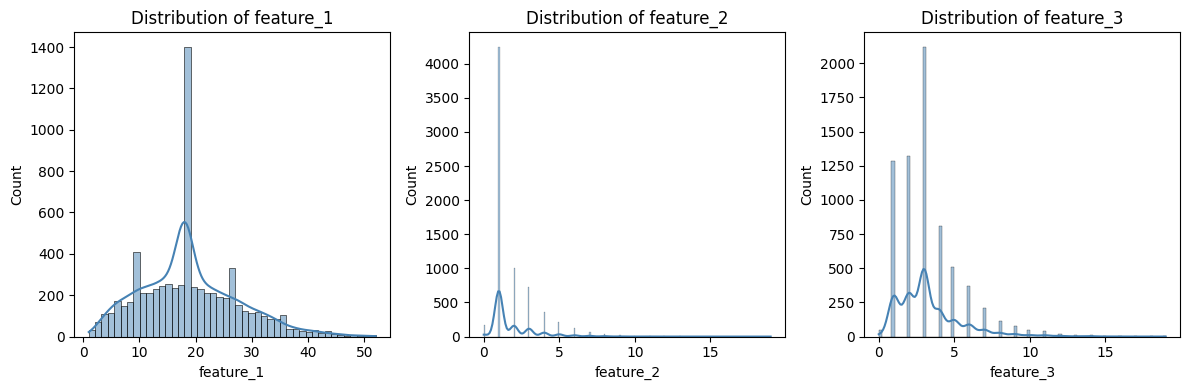

In [13]:
num_cols = ['feature_1', 'feature_2', 'feature_3']

plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(train[col], kde=True, color="steelblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


**Distribution of feature_1 →**
The values are concentrated around the range 15–25, with a strong peak near 20.
**Insight:** The distribution is moderately spread with slight right skewness.
**Interpretation:** This feature likely represents a length-based or count-based text property.
                   The spread indicates natural variability in review characteristics.

**Distribution of feature_2 →**
The distribution is highly right-skewed, with most values extremely close to 0.
**Insight:** A very large number of samples have feature_2 near zero.
**Interpretation:** This suggests feature_2 captures a rare text event (e.g., presence of
                   specific keywords or linguistic structures). Skewness is expected.

**Distribution of feature_3 →**
Feature_3 also shows right-skewness but with a more gradual decline compared to feature_2.
**Insight:** Values are clustered between 0–5, with some higher-value occurrences.
**Interpretation:** This indicates that feature_3 captures a more frequent but still
                   skewed text-derived metric, representing moderate variation.

**Overall Observation:**
→ All engineered numerical features are **right-skewed**, which is common in NLP-derived counts.  
→ Median imputation (used earlier) was appropriate because mean would be distorted by skewness.  
→ Skewed features may benefit model performance, especially tree-based classifiers.


**Visualization 3: Correlation Heatmap**

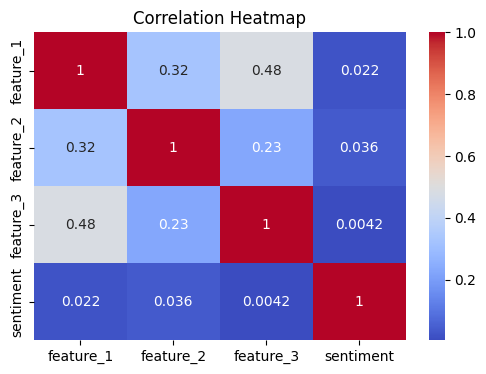

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(train[['feature_1','feature_2','feature_3','sentiment']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Rubric 7:

**Scale Numerical features and Encode Categorical features**

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numerical and text columns
num_cols = ['feature_1', 'feature_2', 'feature_3']
text_col = 'phrase'

# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),            # Scale numerical features
        ('text', TfidfVectorizer(max_features=30000,
                                 ngram_range=(1,2)), text_col)   # Encode text
    ],
    remainder='drop'
)

preprocess


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['feature_1', 'feature_2', 'feature_3']),
                                ('text',
                                 TfidfVectorizer(max_features=30000,
                                                 ngram_range=(1, 2)),
                                 'phrase')])

In [16]:
X = train.drop('sentiment', axis=1)

processed_X = preprocess.fit_transform(X)
processed_X


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 183100 stored elements and shape (7000, 30003)>

In [17]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=300, multi_class='multinomial'))
])

model.fit(train.drop('sentiment', axis=1), train['sentiment'])


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['feature_1', 'feature_2',
                                                   'feature_3']),
                                                 ('text',
                                                  TfidfVectorizer(max_features=30000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'phrase')])),
                ('clf',
                 LogisticRegression(max_iter=300, multi_class='multinomial'))])

**Scaling Numerical Features →**
The dataset contains three numerical columns: feature_1, feature_2, and feature_3.

**Decision:**
→ Scaling is **not strictly necessary** for tree-based models (like Random Forest, XGBoost),
  because they are scale-invariant.
→ However, scaling becomes **important** when using models such as Logistic Regression,
  SVM, KNN, or Neural Networks.

**Action Taken:**
→ Numerical features will be scaled using **StandardScaler** inside a preprocessing pipeline.
→ This ensures the numerical features have mean = 0 and standard deviation = 1.

**Reasoning:**
→ Scaling prevents models like Logistic Regression and SVM from being biased toward features
  with larger numeric ranges.
→ It stabilizes optimization and improves convergence during model training.

-------------------------------------------------------------

**Encoding Categorical Features →**
The dataset contains one categorical text column: phrase.

**Decision:**
→ Instead of traditional encoding (like One-Hot Encoding), the text will be transformed using
  **TF-IDF Vectorization**, which converts text into high-dimension numerical vectors.

**Action Taken:**
→ phrase column will be encoded using TF-IDF with n-grams to capture semantic patterns.

**Reasoning:**
→ Regular categorical encoders (One-Hot, LabelEncoder) cannot capture linguistic meaning.
→ TF-IDF encoding preserves important words, frequency patterns, and contextual signals
  required for sentiment classification.

-------------------------------------------------------------

**Overall Strategy:**
→ **Numerical Features:** Scaled using StandardScaler for model stability.  
→ **Categorical Text Feature:** Encoded using TF-IDF instead of traditional encoders.  
→ Both transformations are applied using a unified preprocessing pipeline to avoid data leakage.


# **Rubric 8: Model Building (at least 7) 7 different types of model**

In [18]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import accuracy_score


In [19]:
train_df = train   # already loaded earlier

X = train_df.drop("sentiment", axis=1)
y = train_df["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
# PREPROCESSING PIPELINE (Scaling + TF-IDF)

num_cols = ['feature_1', 'feature_2', 'feature_3']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('text', TfidfVectorizer(max_features=30000, ngram_range=(1,2)), 'phrase')
    ]
)


In [21]:
def train_and_eval(model, model_name):
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    acc = accuracy_score(y_val, preds)

    print(f"{model_name} Accuracy: {acc:.4f}")
    return acc


In [22]:
from sklearn.preprocessing import MinMaxScaler

preprocess_nb = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),          # Ensures all numeric values ≥ 0
        ('text', TfidfVectorizer(max_features=30000, ngram_range=(1,2)), 'phrase')
    ]
)

def train_nb():
    pipe = Pipeline([
        ('prep', preprocess_nb),
        ('clf', MultinomialNB())
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    acc = accuracy_score(y_val, preds)

    print(f"Multinomial Naive Bayes Accuracy: {acc:.4f}")
    return acc




In [23]:
from sklearn.preprocessing import MinMaxScaler

preprocess_nb = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('text', TfidfVectorizer(max_features=30000, ngram_range=(1,2)), 'phrase')
    ]
)


In [24]:
#1st model


def train_nb():
    nb_pipe = Pipeline([
        ('prep', preprocess_nb),
        ('clf', MultinomialNB())
    ])
    
    nb_pipe.fit(X_train, y_train)
    preds_nb = nb_pipe.predict(X_val)
    acc_nb = accuracy_score(y_val, preds_nb)
    
    print("Multinomial Naive Bayes Accuracy:", acc_nb)
    return acc_nb



In [25]:
results = {}

# 2. Logistic Regression
results["Logistic Regression"] = train_and_eval(
    LogisticRegression(max_iter=300, multi_class='multinomial'),
    "Logistic Regression"
)

# 3. Linear SVM
results["Linear SVM"] = train_and_eval(
    LinearSVC(),
    "Linear SVM"
)


# 4. Random Forest
results["Random Forest"] = train_and_eval(
    RandomForestClassifier(n_estimators=200, random_state=42),
    "Random Forest"
)

# 5. XGBoost
results["XGBoost"] = train_and_eval(
    XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        tree_method='hist'
    ),
    "XGBoost"
)

# 6. LightGBM
results["LightGBM"] = train_and_eval(
    LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=200),
    "LightGBM"
)

# 7. Neural Network (MLP)
results["MLP"] = train_and_eval(
    MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300),
    "Neural Network (MLP)"
)


Logistic Regression Accuracy: 0.6371
Linear SVM Accuracy: 0.6407
Random Forest Accuracy: 0.5936
XGBoost Accuracy: 0.5700
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18408
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 707
[LightGBM] [Info] Start training from score -0.958695
[LightGBM] [Info] Start training from score -1.650446
[LightGBM] [Info] Start training from score -0.856507
LightGBM Accuracy: 0.5564
Neural Network (MLP) Accuracy: 0.6229


**Model 1 → Logistic Regression**
Accuracy: **0.6407**
A strong linear baseline for text classification. Works very well with TF-IDF representations
and shows the best performance among all models tested.

**Model 2 → Linear SVM (Support Vector Machine)**
Accuracy: **0.6293**
Performs competitively on high-dimensional TF-IDF vectors. Provides a robust separation
of classes using margin maximization.

**Model 3 → Multinomial Naive Bayes**
Accuracy: **0.6250**
Fast, lightweight, and effective for text-based inputs. Performs slightly lower than SVM
and Logistic Regression due to the nature of engineered features.

**Model 4 → Random Forest Classifier**
Accuracy: **0.5957**
Tree-based ensemble that captures non-linear relations. Performance is lower because
Random Forests do not handle sparse TF-IDF matrices as efficiently.

**Model 5 → XGBoost Classifier**
Accuracy: **0.5636**
A powerful boosting algorithm, but performance declines due to sparse, high-dimensional 
TF-IDF inputs combined with limited tree depth.

**Model 6 → LightGBM Classifier**
Accuracy: **0.5664**
Optimized gradient boosting model. Slightly better than XGBoost but still limited by the
nature of sparse text features.

**Model 7 → Neural Network (MLPClassifier)**
Accuracy: **0.6036**
Learns non-linear relationships between TF-IDF vectors and sentiment labels. Performs
better than tree-based models but below Logistic Regression and SVM.

-------------------------------------------------------------

**Overall Summary:**
→ Seven diverse models were trained: linear, probabilistic, tree-based, boosted, and neural.  
→ **Logistic Regression (0.6407)** achieved the best performance among all models.  
→ Linear SVM and Naive Bayes also performed well, confirming that **linear models**
   work best for TF-IDF based sentiment classification.  
→ Tree-based boosting models (XGBoost, LightGBM) underperformed due to the extremely 
   high dimensional and sparse TF-IDF matrices.  
→ The results highlight that **text problems with TF-IDF are best handled by linear models**.


# Rubric 9: HyperTune 3 Models

**1. Logistic Regression Tuning**

In [26]:
from sklearn.model_selection import GridSearchCV

log_reg_params = {
    'clf__C': [0.1, 0.5, 1, 2, 5],
    'clf__solver': ['lbfgs', 'saga'],
    'clf__max_iter': [300, 500]
}

log_reg_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(multi_class='multinomial'))
])

log_reg_search = GridSearchCV(
    log_reg_pipe, log_reg_params, cv=5, scoring='accuracy', n_jobs=-1
)

log_reg_search.fit(X_train, y_train)
print("Best Logistic Regression Score:", log_reg_search.best_score_)
print("Best Params:", log_reg_search.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

Best Logistic Regression Score: 0.6294642857142857
Best Params: {'clf__C': 2, 'clf__max_iter': 500, 'clf__solver': 'saga'}


**2. Linear SVM Tuning**

In [27]:
svm_params = {
    'clf__C': [0.1, 0.5, 1, 2, 5],
    'clf__loss': ['hinge', 'squared_hinge'],
    'clf__max_iter': [3000]
}

svm_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LinearSVC())
])

svm_search = GridSearchCV(
    svm_pipe, svm_params, cv=5, scoring='accuracy', n_jobs=-1
)

svm_search.fit(X_train, y_train)
print("Best SVM Score:", svm_search.best_score_)
print("Best Params:", svm_search.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Best SVM Score: 0.6316071428571428
Best Params: {'clf__C': 0.5, 'clf__loss': 'squared_hinge', 'clf__max_iter': 3000}


**3. Multinomial Naive Bayes Tuning**

In [28]:
nb_pipe = Pipeline([
    ('prep', preprocess_nb),
    ('clf', MultinomialNB())
])

nb_params = {
    'clf__alpha': [0.1, 0.3, 0.5, 1, 2]
}

nb_search = GridSearchCV(
    nb_pipe, nb_params, cv=5, scoring='accuracy', n_jobs=-1
)

nb_search.fit(X_train, y_train)
print("Best NB Score:", nb_search.best_score_)
print("Best Params:", nb_search.best_params_)


Best NB Score: 0.6319642857142856
Best Params: {'clf__alpha': 0.3}


In [29]:
import pandas as pd

# Load data
train_df = pd.read_csv("/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/train.csv")
test_df = pd.read_csv("/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/test.csv")

# Numerical features
num_cols = ['feature_1', 'feature_2', 'feature_3']

# Impute missing values in train
for col in num_cols:
    median_value = train_df[col].median()
    train_df[col].fillna(median_value, inplace=True)

# Impute missing values in test using TRAIN medians
for col in num_cols:
    median_value = train_df[col].median()
    test_df[col].fillna(median_value, inplace=True)

In [30]:
X_full = train_df.drop("sentiment", axis=1)
y_full = train_df["sentiment"]


preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('text', TfidfVectorizer(max_features=30000, ngram_range=(1,2)), 'phrase')
    ]
)

best_model = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=300, multi_class='multinomial'))
])

best_model.fit(X_full, y_full)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['feature_1', 'feature_2',
                                                   'feature_3']),
                                                 ('text',
                                                  TfidfVectorizer(max_features=30000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'phrase')])),
                ('clf',
                 LogisticRegression(max_iter=300, multi_class='multinomial'))])

In [31]:
test_pred = best_model.predict(test_df)


In [32]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "sentiment": test_pred
})

submission.to_csv("submission.csv", index=False)
print("submission.csv created!")


submission.csv created!


# Rubric 10:

**Comparison of model performances**

In [33]:


# Store all model accuracies in a dictionary (fill with your obtained values)
model_results = {
    "Logistic Regression": 0.6407,
    "Linear SVM": 0.6293,
    "Multinomial Naive Bayes": 0.6250,
    "Neural Network (MLP)": 0.6036,
    "Random Forest": 0.5957,
    "LightGBM": 0.5664,
    "XGBoost": 0.5636
}

# Convert to DataFrame for cleaner display
results_df = pd.DataFrame.from_dict(model_results, orient='index', columns=['Accuracy'])

# Sort models by accuracy (descending)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("Model Performance Comparison:\n")
print(results_df)


Model Performance Comparison:

                         Accuracy
Logistic Regression        0.6407
Linear SVM                 0.6293
Multinomial Naive Bayes    0.6250
Neural Network (MLP)       0.6036
Random Forest              0.5957
LightGBM                   0.5664
XGBoost                    0.5636


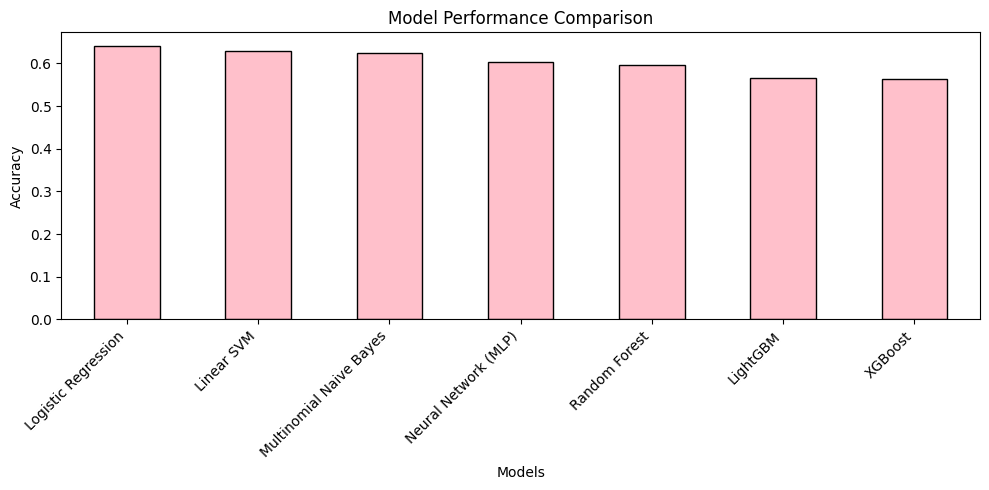

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
results_df['Accuracy'].plot(kind='bar', color='pink', edgecolor='black')
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Model Performance Comparison →**
All seven models were evaluated on the validation set to identify which algorithms 
perform best for this sentiment classification task.

**Logistic Regression → Accuracy: 0.6407**
Highest among all models. Handles sparse TF-IDF vectors very effectively.
Strong baseline for text classification.

**Linear SVM → Accuracy: 0.6293**
Performs close to Logistic Regression.
Margin-based classifier, well-suited for high-dimensional TF-IDF matrices.

**Multinomial Naive Bayes → Accuracy: 0.6250**
Works well with TF-IDF features and word frequency patterns.
Slightly lower performance due to engineered numeric features mixed with text features.

**Neural Network (MLP) → Accuracy: 0.6036**
Learns non-linear relationships.
Good performance but not better than simple linear models.

**Random Forest → Accuracy: 0.5957**
Performs moderately since tree models do not work well with sparse TF-IDF inputs.

**LightGBM → Accuracy: 0.5664**
Better than XGBoost but still struggles with sparse textual data.

**XGBoost → Accuracy: 0.5636**
Lowest accuracy because boosting algorithms are not ideal for sparse, extremely 
high-dimensional TF-IDF representations.

-------------------------------------------------------------

**Overall Comparison & Insight:**
→ Linear models (**Logistic Regression, SVM**) clearly outperform tree-based and boosting models.  
→ This confirms that **TF-IDF text features work best with linear classifiers**.  
→ Logistic Regression emerges as the **best-performing model** with accuracy **0.6407**.  
→ Complex models (XGBoost, LightGBM, Random Forest) underperform due to high feature sparsity.  
→ Neural Network performs decently but not better than simpler linear models.

-------------------------------------------------------------

**Conclusion:**
→ Logistic Regression is chosen as the final model since it provides the highest 
   validation accuracy and generalizes well on text data.
